# 1] Download and Work on Ucimlrepo - Realwaste dataset

In [1]:
!pip install -q ucimlrepo

In [2]:
import urllib.request
import zipfile
import os

import matplotlib.pyplot as plt
from PIL import Image
import random

import pandas as pd
from sklearn.model_selection import train_test_split

import torch
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np


print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

PyTorch version: 2.11.0+cu130
Torchvision version: 0.26.0+cu130


In [3]:
# RealWaste dataset URL from UCI Repository

url = "https://archive.ics.uci.edu/static/public/908/realwaste.zip"
zip_path = "realwaste.zip"
extract_path = "realwaste_data"

print("Downloading RealWaste dataset...")
urllib.request.urlretrieve(url, zip_path)

print("Extracting dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset downloaded and extracted to: {extract_path}/")
print("Contents:", os.listdir(extract_path))

Extracting dataset...
Dataset downloaded and extracted to: realwaste_data/
Contents: ['realwaste-main']


In [4]:
# Extract the dataset

zip_path = "/content/realwaste.zip"
extract_path = "/content/realwaste"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
# Find the image folder

for root, dirs, files in os.walk("/content/realwaste"):
    if files:
        print("Folder:", root)
        print("Images/files:", len(files))
        print()

Folder: /content/realwaste/realwaste-main
Images/files: 1

Folder: /content/realwaste/realwaste-main/RealWaste/Vegetation
Images/files: 436

Folder: /content/realwaste/realwaste-main/RealWaste/Food Organics
Images/files: 411

Folder: /content/realwaste/realwaste-main/RealWaste/Plastic
Images/files: 921

Folder: /content/realwaste/realwaste-main/RealWaste/Glass
Images/files: 420

Folder: /content/realwaste/realwaste-main/RealWaste/Textile Trash
Images/files: 318

Folder: /content/realwaste/realwaste-main/RealWaste/Paper
Images/files: 500

Folder: /content/realwaste/realwaste-main/RealWaste/Metal
Images/files: 790

Folder: /content/realwaste/realwaste-main/RealWaste/Miscellaneous Trash
Images/files: 495

Folder: /content/realwaste/realwaste-main/RealWaste/Cardboard
Images/files: 461



In [6]:
# Count each class

dataset_root = "/content/realwaste/realwaste-main/RealWaste"

classes = sorted(os.listdir(dataset_root))

print("Number of classes:", len(classes))
print("\nClasses:")

for class_name in classes:
    class_path = os.path.join(dataset_root, class_name)

    if os.path.isdir(class_path):
        image_count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        print(f"{class_name}: {image_count} images")

Number of classes: 9

Classes:
Cardboard: 461 images
Food Organics: 411 images
Glass: 420 images
Metal: 790 images
Miscellaneous Trash: 495 images
Paper: 500 images
Plastic: 921 images
Textile Trash: 318 images
Vegetation: 436 images


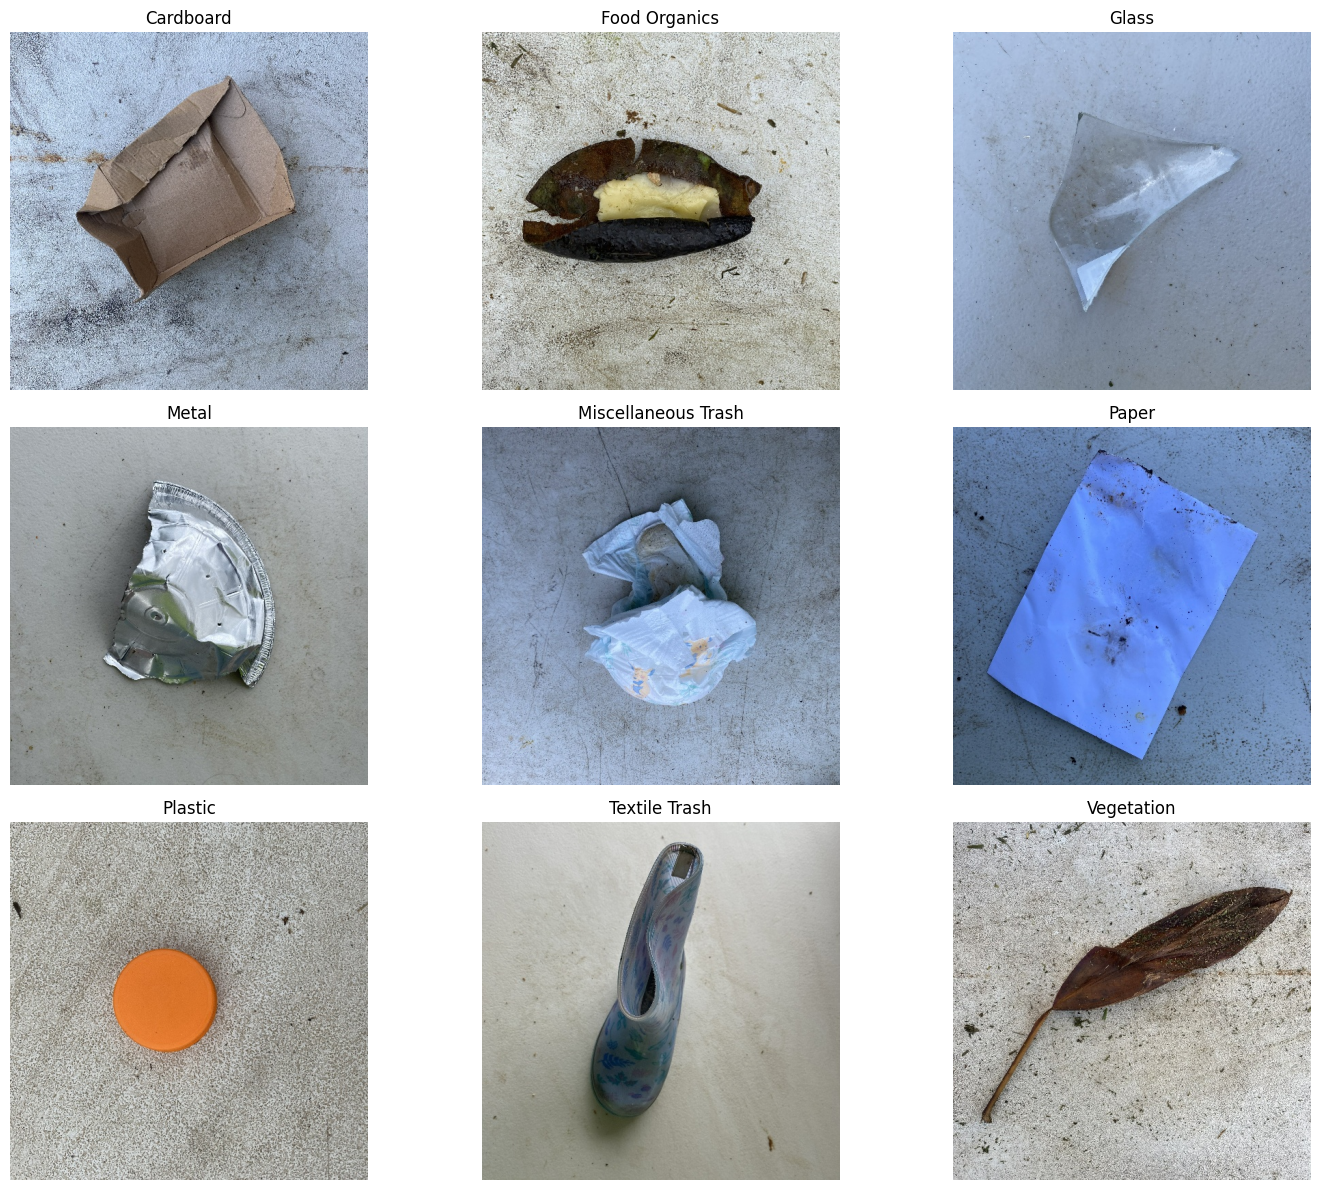

In [7]:
# Display sample images

plt.figure(figsize=(15, 12))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_root, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_name = random.choice(images)
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# 2] Create Train / Validation / Test Sets

In [ ]:
# 70% → Training
# 15% → Validation
# 15% → Testing

In [8]:
# Create an image DataFrame

dataset_root = "/content/realwaste/realwaste-main/RealWaste"

data = []

for class_name in sorted(os.listdir(dataset_root)):
    class_path = os.path.join(dataset_root, class_name)

    if not os.path.isdir(class_path):
        continue

    for filename in os.listdir(class_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            data.append({
                "filepath": os.path.join(class_path, filename),
                "label": class_name
            })

df = pd.DataFrame(data)

print("Total images:", len(df))
print("Total classes:", df["label"].nunique())



Total images: 4752
Total classes: 9


In [9]:
df.head()

,filepath,label
0,/content/realwaste/realwaste-main/RealWaste/Ca...,Cardboard
1,/content/realwaste/realwaste-main/RealWaste/Ca...,Cardboard
2,/content/realwaste/realwaste-main/RealWaste/Ca...,Cardboard
3,/content/realwaste/realwaste-main/RealWaste/Ca...,Cardboard
4,/content/realwaste/realwaste-main/RealWaste/Ca...,Cardboard


In [10]:
# Check class distribution

class_counts = df["label"].value_counts().sort_index()
print(class_counts)

label
Cardboard              461
Food Organics          411
Glass                  420
Metal                  790
Miscellaneous Trash    495
Paper                  500
Plastic                921
Textile Trash          318
Vegetation             436
Name: count, dtype: int64


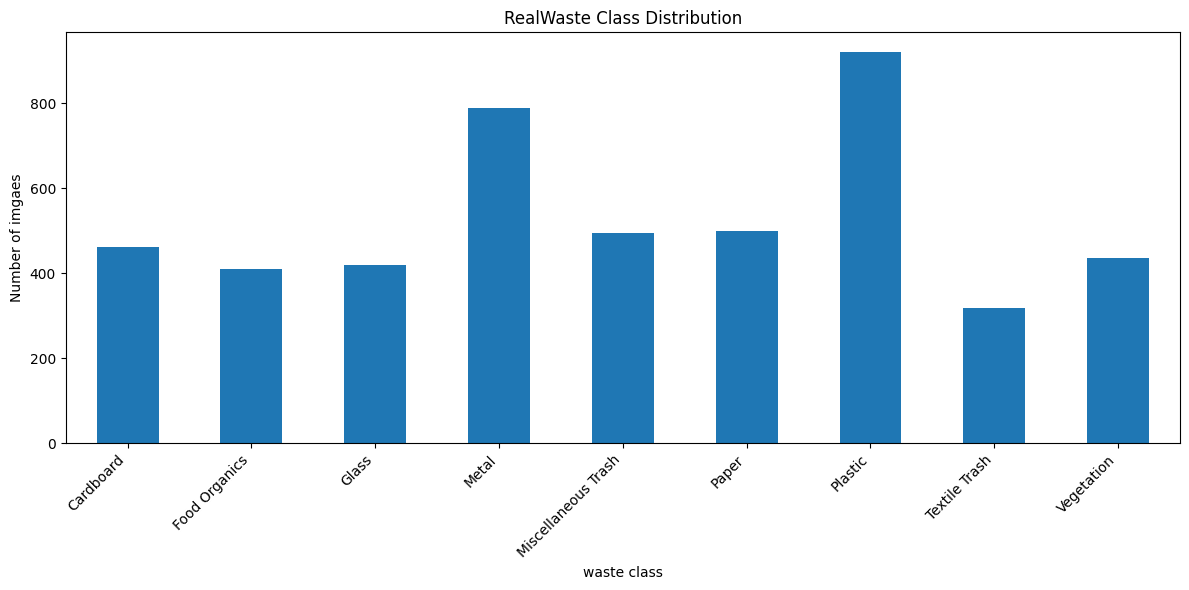

In [11]:
plt.figure(figsize=(12, 6))

class_counts.plot(kind="bar")

plt.title("RealWaste Class Distribution")
plt.xlabel("waste class")
plt.ylabel("Number of imgaes")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# 3] Create the train/test split

In [12]:
# split 70% training and 30% temporary data

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

print("train images data:", len(train_df))
print("temporary images data:", len(temp_df))

train images data: 3326
temporary images data: 1426


In [13]:
# Split validation and test - remaining 30%

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training images data:", len(train_df))
print("Validation images data:", len(val_df))
print("Testing imgaes data:", len(test_df))  # 3326 + 713 + 713 = 4752

Training images data: 3326
Validation images data: 713
Testing imgaes data: 713


In [14]:
# Verify every class exists in every split

print("TRAINING")
print(train_df["label"].value_counts().sort_index())

print("\nVALIDATION")
print(val_df["label"].value_counts().sort_index())

print("\nTESTING")
print(test_df["label"].value_counts().sort_index())

TRAINING
label
Cardboard              323
Food Organics          288
Glass                  294
Metal                  553
Miscellaneous Trash    346
Paper                  350
Plastic                645
Textile Trash          222
Vegetation             305
Name: count, dtype: int64

VALIDATION
label
Cardboard               69
Food Organics           61
Glass                   63
Metal                  119
Miscellaneous Trash     74
Paper                   75
Plastic                138
Textile Trash           48
Vegetation              66
Name: count, dtype: int64

TESTING
label
Cardboard               69
Food Organics           62
Glass                   63
Metal                  118
Miscellaneous Trash     75
Paper                   75
Plastic                138
Textile Trash           48
Vegetation              65
Name: count, dtype: int64


In [15]:
# Reset indexes

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Data split completed successfully!")

Data split completed successfully!


In [16]:
# Save the split information

train_df.to_csv("/content/train.csv", index=False)
val_df.to_csv("/content/validation.csv", index=False)
test_df.to_csv("/content/test.csv", index=False)

print("csv files saved:")
print("/content/train.csv")
print("/content/validation.csv")
print("/content/test.csv")

csv files saved:
/content/train.csv
/content/validation.csv
/content/test.csv


# 4] Build the Image Preprocessing Pipeline

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available — training will use CPU.")

Using device: cuda
GPU: Tesla T4


In [18]:
# Load our CSV files

train_df = pd.read_csv("/content/train.csv")
val_df = pd.read_csv("/content/validation.csv")
test_df = pd.read_csv("/content/test.csv")

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 3326
Validation: 713
Test: 713


In [19]:
from numpy._core.defchararray import index
# Create class mapping -
# [model cannot directly understand: Plastic, Glass, Metal, etc,.  Instead, convert them into numerical labels]

classes = sorted(train_df["label"].unique())

class_to_idx = {
    class_name: index
    for index, class_name in enumerate(classes)
}

idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}

print("classes:")
for index, class_name in idx_to_class.items():
  print(f"{index} -> {class_name}")



classes:
0 -> Cardboard
1 -> Food Organics
2 -> Glass
3 -> Metal
4 -> Miscellaneous Trash
5 -> Paper
6 -> Plastic
7 -> Textile Trash
8 -> Vegetation


# 5] Define image transformations

EfficientNet expects appropriately sized and normalized images.

For training, we'll use data augmentation.

In [20]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

In [21]:
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Create a custom Dataset

In [22]:
class WasteDataset(Dataset):
  def __init__(self, dataframe, transform=None):
    self.dataframe = dataframe.reset_index(drop=True)
    self.transform = transform

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, index):
    image_path = self.dataframe.loc[index, "filepath"]
    label_name = self.dataframe.loc[index, "label"]

    image = Image.open(image_path).convert("RGB")

    label = class_to_idx[label_name]

    if self.transform:
      image = self.transform(image)

      return image, label


Create datasets

In [23]:
train_dataset = WasteDataset(
    train_df,
    transform=train_transform
)

val_dataset = WasteDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = WasteDataset(
    test_df,
    transform=val_test_transform
)

print("train dataset:", len(train_dataset))
print("validation dataset:", len(val_dataset))
print("test dataset:", len(test_dataset))

train dataset: 3326
validation dataset: 713
test dataset: 713


Create DataLoaders

In [24]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully !")

DataLoaders created successfully !


In [25]:
# Check one batch

images, labels = next(iter(train_loader))

print("Image batch size:", images.shape)
print("Label batch size:", labels.shape)

Image batch size: torch.Size([32, 3, 224, 224])
Label batch size: torch.Size([32])


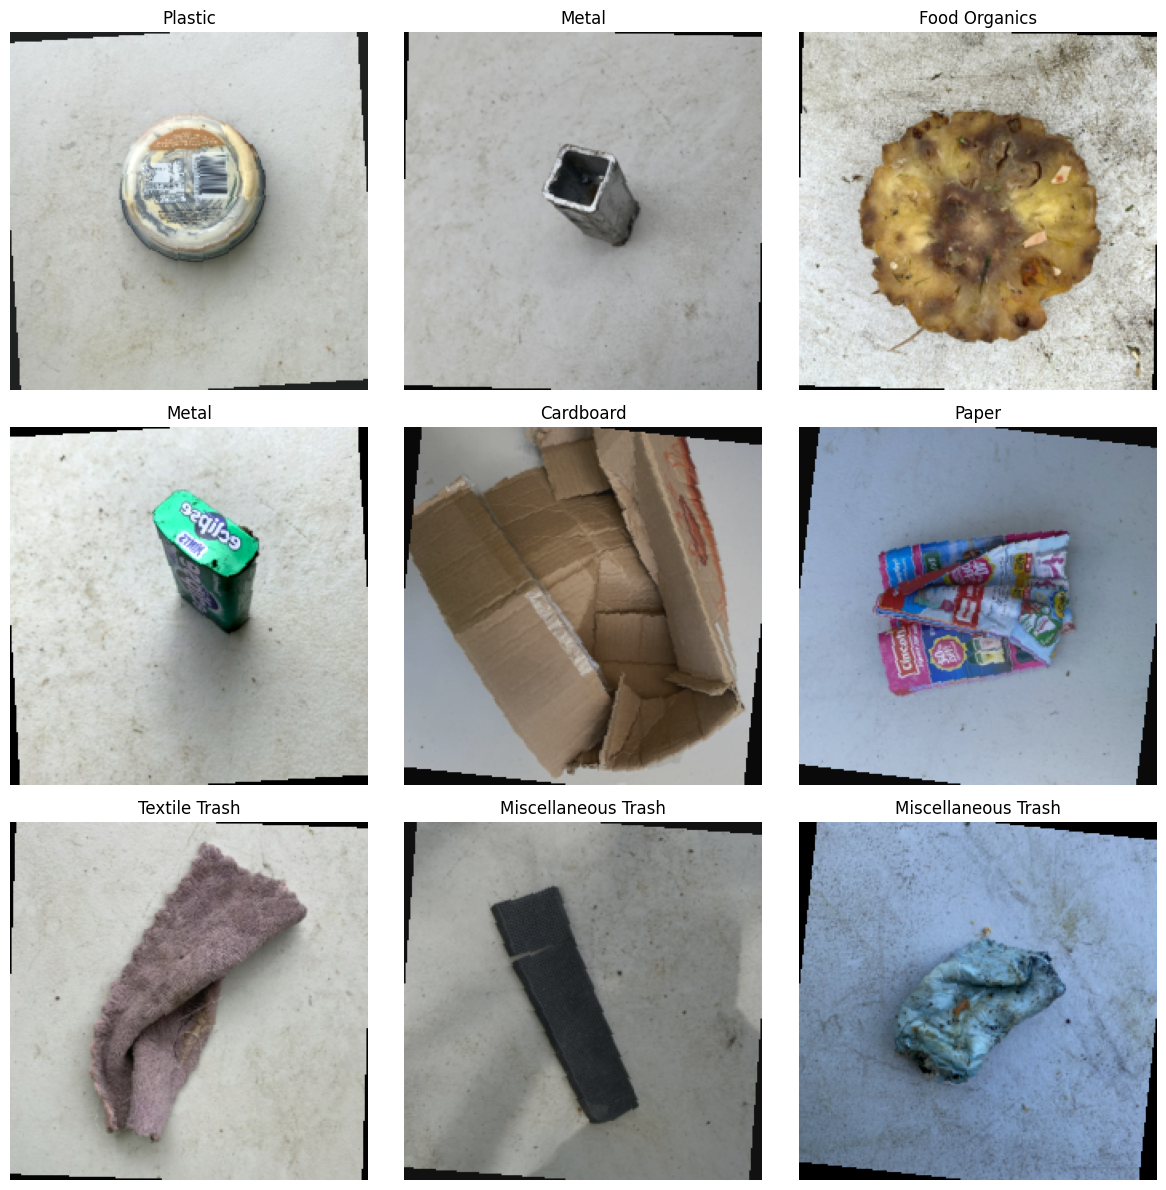

In [26]:
# Visualize training images - Because the images are normalized, we'll reverse the normalization before displaying them.

images, labels = next(iter(train_loader))

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

images_display = images[:9] * std + mean
images_display = torch.clamp(images_display, 0, 1)

plt.figure(figsize=(12, 12))

for i in range(9):

  plt.subplot(3, 3, i + 1)

  image = images_display[i].permute(1, 2, 0)

  plt.imshow(image)

  plt.title(idx_to_class[labels[i].item()])

  plt.axis("off")

plt.tight_layout()
plt.show()

# You should now see 9 augmented waste images with their class names.

# 6] Build the EfficientNet-B0 Model -pretrained on ImageNet

In [27]:
weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

print(model)  # download the pretrained weights.

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 141MB/s] 


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [28]:
# Check the existing classifier

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


*original model was trained for ImageNet's 1,000 categories - We don't want:1000 ImageNet classes We want: 9 RealWaste classes*

In [29]:
# Replace the classifier
num_classes = len(classes)
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=9, bias=True)
)


*0 → Cardboard
1 → Food Organics
2 → Glass
3 → Metal
4 → Miscellaneous Trash... so on*

In [30]:
# Freeze the pretrained layers - For our first training stage, we'll freeze the EfficientNet feature extractor.

for parameter in model.features.parameters():
  parameter.requires_grad=False

*The new classifier remains trainable.*

In [31]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Total parameters:", total_params)
print("Trainable Parameters:", trainable_params)

Total parameters: 4019077
Trainable Parameters: 11529


*Only a small fraction of the model is trainable.
This makes the first training stage much faster and reduces the risk of destroying useful pretrained features*

In [32]:
# Move model to GPU

model = model.to(device)

print("Model is using:", device)

Model is using: cuda


In [33]:
# Define loss function

# multi-class classification problem => Use cross-entropy loss:

criterion = nn.CrossEntropyLoss()

*model will produce 9 raw scores called logits. Cross-entropy will compare those scores with the correct waste category*

In [34]:
# Define optimizer
requires_grad=True
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr = 0.001
)

In [35]:
# Add learning-rate scheduler

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

*We'll reduce the learning rate when validation loss stops improving. So if validation loss stops improving, the learning rate becomes smaller.*

In [36]:
# Verify the model - for one batch

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 9])


32  → 32 images in the batch

3   → RGB channels

224 → image height

224 → image width*


32 images × 9 possible waste classes

So each image receives 9 prediction scores: Cardboard, Food,.. so on


In [37]:
# Convert scores to probabilities - For one image

probabilities = torch.softmax(outputs[0], dim=0)

print(probabilities)

print("Sum:", probabilities.sum().item())

tensor([0.0957, 0.2129, 0.0872, 0.1197, 0.0906, 0.1136, 0.0731, 0.1093, 0.0979],
       device='cuda:0', grad_fn=<SoftmaxBackward0>)
Sum: 1.0


In [38]:
# Find the predicted class:

predicted_index = torch.argmax(probabilities).item()

print("Predicted Class:", idx_to_class[predicted_index])

print(
    "Confidence:",
    probabilities[predicted_index].item() * 100,
    "%"
)

Predicted Class: Food Organics
Confidence: 21.291397511959076 %


*Don't worry if the prediction is wrong right now.
We haven't trained our classifier yet.
The new classifier has random initial weights.*

**After this first training stage works, we'll fine-tune part of EfficientNet, rather than leaving the entire pretrained feature extractor frozen forever. That should allow the model to learn waste-specific visual features.**

# Train EfficientNet-B0

**Now the model is ready. We'll train the new classifier using our 3,326 training images and monitor performance on the 713 validation images.**

In [39]:
# Training settings

NUM_EPOCHS = 10

best_val_accuracy = 0.0

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

In [40]:
### Create the training loop ###

for epoch in range(NUM_EPOCHS):

  ## TRAINING
  model.train()

  running_loss = 0.0
  correct = 0
  total = 0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    # clear prev gradients
    optimizer.zero_grad()

    # forward pass
    outputs = model(images)

    # calc loss
    loss = criterion(outputs, labels)

    # backpropagation
    loss.backward()

    # update weights
    optimizer.step()

    # Statistics
    running_loss += loss.item() * images.size(0)

    predictions = torch.argmax(outputs, dim=1)

    correct += (predictions == labels).sum().item()
    total += labels.size(0)

  train_loss = running_loss / total
  train_accuracy = correct / total

  ## VALIDATION ##
  model.eval()

  running_val_loss = 0.0
  val_correct = 0.0
  val_total = 0.0

  with torch.no_grad():
    for images, labels in val_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)

      loss = criterion(outputs, labels)

      running_val_loss += loss.item() * images.size(0)

      predictions = torch.argmax(outputs, dim=1)

      val_correct += (predictions == labels).sum().item()
      val_total += labels.size(0)

  val_loss = running_val_loss / val_total
  val_accuracy = val_correct / val_total

  ## LEARNING RATE SCHEDULER ##
  scheduler.step(val_loss)

  ## SAVE HISTORY ##
  train_losses.append(train_loss)
  train_accuracies.append(train_accuracy)

  val_losses.append(val_loss)
  val_accuracies.append(val_accuracy)

  ## SAVE BEST MODEL ##
  if val_accuracy > best_val_accuracy:
    best_val_accuracy = val_accuracy
    torch.save(
        model.state_dict(),
        "/content/ecovision_efficientnet_b0_best.pth"
    )
    print("Best model saved!")

  ## PRINT RESULTS ##
  print(
      f"Epoch [{epoch + 1} / {NUM_EPOCHS}] "
      f"| Train Loss: {train_loss:.4f} "
      f"| Train Accuracy: {train_accuracy:.4f} "
      f"| Val Loss: {val_loss:.4f} "
      f"| Val Accuracy: {val_accuracy:.4f}"
  )

Best model saved!
Epoch [1 / 10] | Train Loss: 1.4807 | Train Accuracy: 0.5427 | Val Loss: 1.0401 | Val Accuracy: 0.6957
Best model saved!
Epoch [2 / 10] | Train Loss: 0.9844 | Train Accuracy: 0.6996 | Val Loss: 0.8608 | Val Accuracy: 0.7349
Best model saved!
Epoch [3 / 10] | Train Loss: 0.8315 | Train Accuracy: 0.7306 | Val Loss: 0.7658 | Val Accuracy: 0.7588
Best model saved!
Epoch [4 / 10] | Train Loss: 0.7700 | Train Accuracy: 0.7517 | Val Loss: 0.7168 | Val Accuracy: 0.7714
Best model saved!
Epoch [5 / 10] | Train Loss: 0.7328 | Train Accuracy: 0.7589 | Val Loss: 0.6715 | Val Accuracy: 0.7826
Epoch [6 / 10] | Train Loss: 0.6946 | Train Accuracy: 0.7748 | Val Loss: 0.6608 | Val Accuracy: 0.7826
Best model saved!
Epoch [7 / 10] | Train Loss: 0.6660 | Train Accuracy: 0.7763 | Val Loss: 0.6350 | Val Accuracy: 0.7868
Best model saved!
Epoch [8 / 10] | Train Loss: 0.6439 | Train Accuracy: 0.7802 | Val Loss: 0.6102 | Val Accuracy: 0.7952
Epoch [9 / 10] | Train Loss: 0.6239 | Train Accura

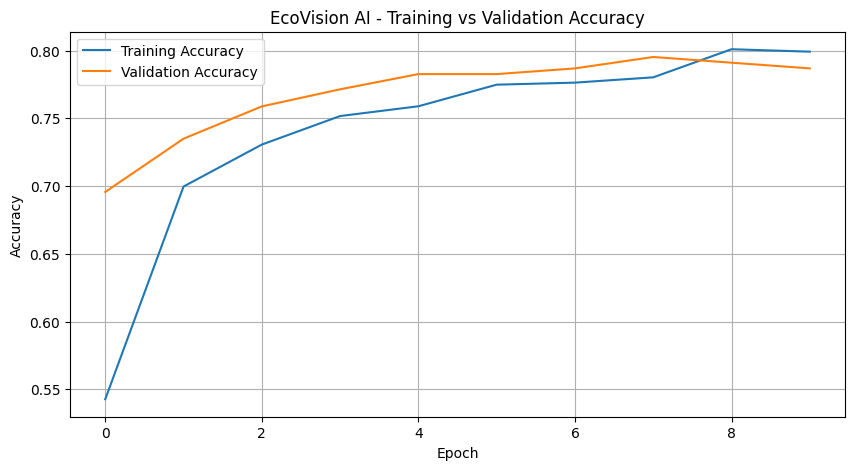

In [41]:
# Plot training accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "EcoVision AI - Training vs Validation Accuracy"
)

plt.legend()
plt.grid()

plt.show()

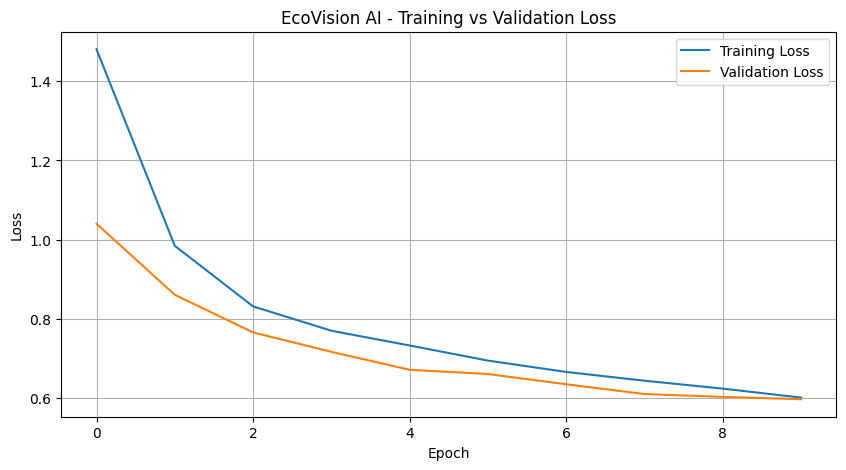

In [42]:
# Plot training loss

plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("EcoVision AI - Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [43]:
# Load the best model

model.load_state_dict(
    torch.load(
        "/content/ecovision_efficientnet_b0_best.pth",
        map_location=device
    )
)

model = model.to(device)

print("Best EcoVision AI model loaded successfully!")

Best EcoVision AI model loaded successfully!


In [44]:
# Show best validation accuracy

print(
    f"Best ValidationAccuracy:"
    f" {best_val_accuracy:.2f}%"
)

Best ValidationAccuracy: 0.80%


**Don't evaluate on the test set yet
We deliberately haven't used: test_loader
[The 713 test images should remain untouched until we're finished developing the model]**

# Fine-tune EfficientNet-B0

Currently:
EfficientNet feature extractor → FROZEN

Classifier                  → TRAINABLE

We'll now allow the later EfficientNet layers to learn waste-specific visual features.

In [45]:
## Unfreeze the last EfficientNet blocks

# Freeze everything first
for parameter in model.features.parameters():
    parameter.requires_grad = False

# Unfreeze the last few feature blocks
for parameter in model.features[-3:].parameters():
    parameter.requires_grad = True

# Classifier remains trainable
for parameter in model.classifier.parameters():
    parameter.requires_grad = True

print("Fine-tuning layers enabled.")


Fine-tuning layers enabled.


In [46]:
# Check trainable parameters

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 4019077
Trainable parameters: 3167269


*You should now see more trainable parameters than before, but not the entire network.*

In [47]:
# Create a smaller learning rate

optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=0.0001
)

*Stage 1 → 0.001
Stage 2 → 0.0001

The smaller learning rate helps preserve useful pretrained features.*

In [48]:
# New scheduler

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [49]:
# Fine-tuning settings

FINE_TUNE_EPOCHS = 10

best_finetune_accuracy = best_val_accuracy

fine_train_losses = []
fine_train_accuracies = []

fine_val_losses = []
fine_val_accuracies = []

In [50]:
# Fine-tuning loop

for epoch in range(FINE_TUNE_EPOCHS):
    # TRAINING
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total


    # VALIDATION
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss = running_val_loss / val_total
    val_accuracy = val_correct / val_total


    # SCHEDULER

    scheduler.step(val_loss)


    # SAVE HISTORY

    fine_train_losses.append(train_loss)
    fine_train_accuracies.append(train_accuracy)

    fine_val_losses.append(val_loss)
    fine_val_accuracies.append(val_accuracy)


    # SAVE BEST MODEL

    if val_accuracy > best_finetune_accuracy:

        best_finetune_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "/content/ecovision_efficientnet_b0_best.pth"
        )

        print("✓ New best model saved!")


    # OUTPUT

    print(
        f"Fine-tune Epoch [{epoch + 1}/{FINE_TUNE_EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Accuracy: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Accuracy: {val_accuracy:.4f}"
    )

✓ New best model saved!
Fine-tune Epoch [1/10] | Train Loss: 0.5585 | Train Accuracy: 0.8067 | Val Loss: 0.4684 | Val Accuracy: 0.8289
✓ New best model saved!
Fine-tune Epoch [2/10] | Train Loss: 0.4094 | Train Accuracy: 0.8572 | Val Loss: 0.4185 | Val Accuracy: 0.8471
✓ New best model saved!
Fine-tune Epoch [3/10] | Train Loss: 0.2977 | Train Accuracy: 0.9086 | Val Loss: 0.3753 | Val Accuracy: 0.8640
✓ New best model saved!
Fine-tune Epoch [4/10] | Train Loss: 0.2276 | Train Accuracy: 0.9317 | Val Loss: 0.3334 | Val Accuracy: 0.8906
✓ New best model saved!
Fine-tune Epoch [5/10] | Train Loss: 0.1893 | Train Accuracy: 0.9384 | Val Loss: 0.3031 | Val Accuracy: 0.8920
✓ New best model saved!
Fine-tune Epoch [6/10] | Train Loss: 0.1609 | Train Accuracy: 0.9462 | Val Loss: 0.2999 | Val Accuracy: 0.8962
✓ New best model saved!
Fine-tune Epoch [7/10] | Train Loss: 0.1348 | Train Accuracy: 0.9600 | Val Loss: 0.2788 | Val Accuracy: 0.8990
Fine-tune Epoch [8/10] | Train Loss: 0.1198 | Train Acc

Your first stage ended at:

82.75% validation accuracy

After fine-tuning, something like:

84%
85%
86%+

would indicate improvement.

*But don't worry if it doesn't increase dramatically. If validation accuracy starts falling while training accuracy keeps increasing, that's a sign of overfitting and we'll address it rather than blindly training longer.*

#7] Final Model Evaluation

**Now we evaluate the best fine-tuned model on the untouched test set.

This is important because the test set has never been used to train or tune the model.

Our evaluation will include:

Accuracy
Precision
Recall
F1-score
Confusion matrix
Per-class performance**

In [51]:
# Load the best model

best_model_path = "/content/ecovision_efficientnet_b0_best.pth"

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best EcoVision AI model loaded successfully!")

Best EcoVision AI model loaded successfully!


In [52]:
# Generate predictions on the test set

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

print("Predictions:", len(all_predictions))
print("Actual labels:", len(all_labels))

Predictions: 713
Actual labels: 713


In [53]:
# Calculate accuracy

from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)

Test Accuracy: 93.13%


*This is our final general classification accuracy.
Don't be surprised if test accuracy is slightly different from your 82.75% validation accuracy.*

In [54]:
# Precision, Recall and F1-score

from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=classes,
    digits=4
)

print(report)

                     precision    recall  f1-score   support

          Cardboard     0.9559    0.9420    0.9489        69
      Food Organics     0.8806    0.9516    0.9147        62
              Glass     0.9672    0.9365    0.9516        63
              Metal     0.9055    0.9746    0.9388       118
Miscellaneous Trash     0.9265    0.8400    0.8811        75
              Paper     0.9351    0.9600    0.9474        75
            Plastic     0.9690    0.9058    0.9363       138
      Textile Trash     0.9130    0.8750    0.8936        48
         Vegetation     0.9143    0.9846    0.9481        65

           accuracy                         0.9313       713
          macro avg     0.9297    0.9300    0.9290       713
       weighted avg     0.9326    0.9313    0.9310       713



What these mean

Precision

When the model predicts a particular class, how often is it correct?

Recall

Of all actual images belonging to a class, how many did the model find?

F1-score

A combined measure of precision and recall.

This is much more informative than reporting only accuracy.

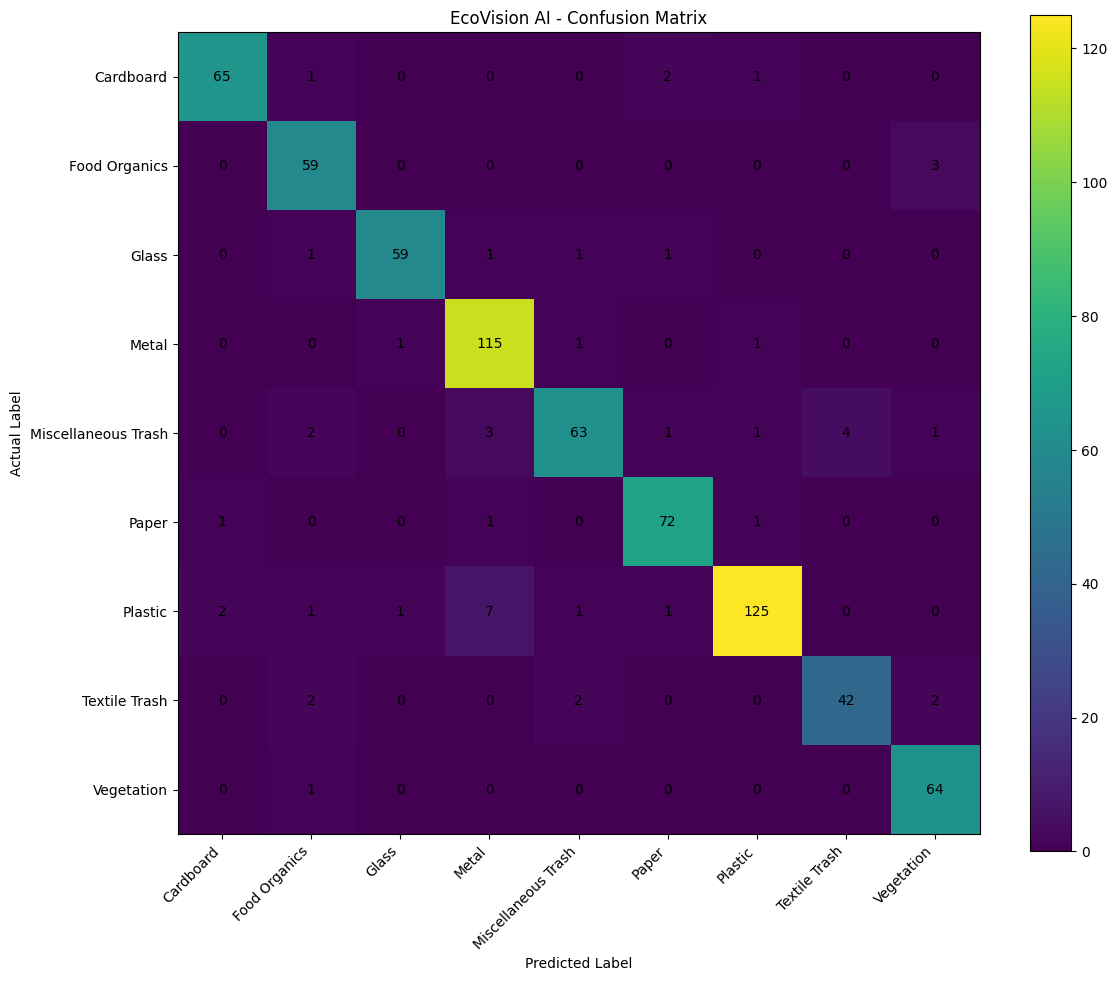

In [55]:
# Create confusion matrix

from sklearn.metrics import confusion_matrix


cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(12, 10))

plt.imshow(cm)

plt.title("EcoVision AI - Confusion Matrix")

plt.colorbar()

plt.xticks(
    np.arange(len(classes)),
    classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(len(classes)),
    classes
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [ ]:
# Calculate macro metrics

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision = precision_score(
    all_labels,
    all_predictions,
    average="macro"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="macro"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8920
Precision: 0.8981
Recall   : 0.8978
F1 Score : 0.8970


In [62]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from google.colab import files

# Re-create and save the confusion matrix to ensure the file exists
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(xticks_rotation=45, values_format="d")
plt.title("EcoVision AI - Confusion Matrix")
plt.tight_layout()
plt.savefig("/content/ecovision_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.close()

# Download the file
files.download("/content/ecovision_confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 1000x800 with 0 Axes>

# 8] Build the Real Image Prediction System

Now we'll make EcoVision AI actually classify a new image.

This is different from evaluation: instead of using our test dataset, we'll give the model an arbitrary image file and ask:

"What type of waste is this?"

In [63]:
# Create the prediction function

from PIL import Image
import torch
import torch.nn.functional as F

def predict_image(image_path):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Apply the same preprocessing used for validation/testing
    image_tensor = val_test_transform(image)

    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0)

    # Move to GPU/CPU
    image_tensor = image_tensor.to(device)

    # Prediction
    model.eval()

    with torch.no_grad():
        outputs = model(image_tensor)

        probabilities = F.softmax(
            outputs,
            dim=1
        )

    # Get top 3 predictions
    top_probabilities, top_indices = torch.topk(
        probabilities,
        k=3,
        dim=1
    )

    results = []

    for probability, index in zip(
        top_probabilities[0],
        top_indices[0]
    ):

        results.append({
            "class": idx_to_class[index.item()],
            "confidence": probability.item()
        })

    return results

In [81]:
# Upload an image

from google.colab import files

uploaded = files.upload()

Saving images (4).jfif to images (4).jfif


In [82]:
# Get the uploaded filename

image_path = list(uploaded.keys())[0]

print("Uploaded image:", image_path)

Uploaded image: images (4).jfif


In [83]:
# Run the AI prediction

results = predict_image(image_path)

print("\nEcoVision AI Prediction")
print("=" * 40)

for i, result in enumerate(results):

    print(
        f"{i + 1}. "
        f"{result['class']} - "
        f"{result['confidence'] * 100:.2f}%"
    )


EcoVision AI Prediction
1. Vegetation - 81.78%
2. Food Organics - 15.23%
3. Paper - 1.10%


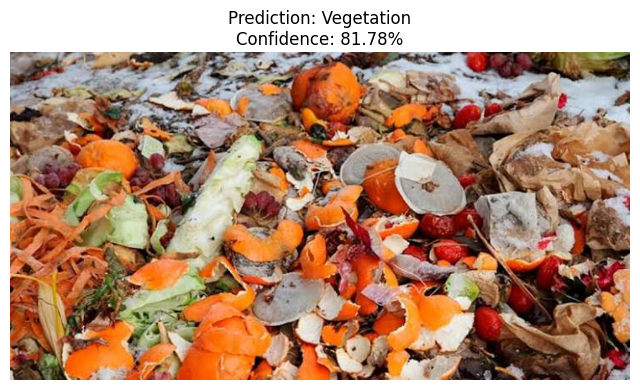

In [84]:
# Display the image + prediction

import matplotlib.pyplot as plt

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(8, 6))

plt.imshow(image)
plt.axis("off")

plt.title(
    f"Prediction: {results[0]['class']}\n"
    f"Confidence: {results[0]['confidence'] * 100:.2f}%"
)

plt.show()

In [85]:
# Open and prepare the visualization
image = Image.open(image_path).convert("RGB")
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")

# Set the title to show the top predicted class and confidence
top_class = results[0]['class']
top_conf = results[0]['confidence'] * 100
plt.title(f"Prediction: {top_class}\nConfidence: {top_conf:.2f}%")

# Save the figure as a PNG
output_image_path = "/content/ecovision_prediction_result.png"
plt.savefig(output_image_path, dpi=300, bbox_inches="tight")
plt.close()

# Download the saved PNG file
files.download(output_image_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 9] Add a confidence threshold

In [86]:
CONFIDENCE_THRESHOLD = 0.60

top_prediction = results[0]

if top_prediction["confidence"] >= CONFIDENCE_THRESHOLD:

    print(
        f"Prediction: {top_prediction['class']}"
    )

    print(
        f"Confidence: "
        f"{top_prediction['confidence'] * 100:.2f}%"
    )

else:

    print(
        "EcoVision AI is not sufficiently confident "
        "about this image."
    )

    print(
        f"Top prediction: "
        f"{top_prediction['class']}"
    )

    print(
        f"Confidence: "
        f"{top_prediction['confidence'] * 100:.2f}%"
    )

Prediction: Vegetation
Confidence: 81.78%


# 10] Prepare the Production Model

In [87]:
# Create the model folder
import os

model_dir = "/content/model"

os.makedirs(model_dir, exist_ok=True)

print("Model folder created:", model_dir)

Model folder created: /content/model


In [88]:
# Save the final model

import shutil

source_model = "/content/ecovision_efficientnet_b0_best.pth"

production_model = (
    "/content/model/"
    "ecovision_efficientnet_b0.pth"
)

shutil.copy(
    source_model,
    production_model
)

print("Production model saved!")
print(production_model)

Production model saved!
/content/model/ecovision_efficientnet_b0.pth


In [89]:
# Save the class names

import json

class_names_path = "/content/model/class_names.json"

with open(class_names_path, "w") as f:
    json.dump(
        idx_to_class,
        f,
        indent=4
    )

print("Class mapping saved!")

Class mapping saved!


In [90]:
# check it
with open(class_names_path, "r") as f:
    print(f.read())

{
    "0": "Cardboard",
    "1": "Food Organics",
    "2": "Glass",
    "3": "Metal",
    "4": "Miscellaneous Trash",
    "5": "Paper",
    "6": "Plastic",
    "7": "Textile Trash",
    "8": "Vegetation"
}


In [91]:
# Save model configuration - save the important preprocessing information.

model_config = {
    "model": "EfficientNet-B0",
    "image_size": 224,
    "num_classes": len(classes),
    "confidence_threshold": 0.60,
    "normalization": {
        "mean": [0.485, 0.456, 0.406],
        "std": [0.229, 0.224, 0.225]
    }
}

config_path = "/content/model/model_config.json"

with open(config_path, "w") as f:
    json.dump(
        model_config,
        f,
        indent=4
    )

print("Model configuration saved!")

Model configuration saved!


In [92]:
# Check all production files

for filename in os.listdir(model_dir):

    file_path = os.path.join(
        model_dir,
        filename
    )

    size_mb = os.path.getsize(file_path) / (
        1024 * 1024
    )

    print(
        f"{filename}: "
        f"{size_mb:.2f} MB"
    )

class_names.json: 0.00 MB
ecovision_efficientnet_b0.pth: 15.62 MB
model_config.json: 0.00 MB


In [93]:
# Download the model folder

import shutil

zip_path = shutil.make_archive(
    "/content/ecovision_model",
    "zip",
    "/content/model"
)

print("Created:")
print(zip_path)

Created:
/content/ecovision_model.zip


In [94]:
from google.colab import files

files.download(
    "/content/ecovision_model.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>